In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import random

In [14]:
def gaussian_kernel(X, Y, sigma):
    """Compute Gaussian kernel matrix: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-dist_sq / (2 * sigma ** 2))

def auto_select_sigma(X, multiplier=5):
    """Select sigma using the paper's strategy: sigma = multiplier * mean(d_NN).
    For each data point, compute the distance to its nearest neighbor,
    then set sigma = multiplier * mean of all nearest-neighbor distances.
    """
    from scipy.spatial.distance import cdist
    D = cdist(X, X, metric='euclidean')
    np.fill_diagonal(D, np.inf)  # exclude self-distance
    d_nn = np.min(D, axis=1)     # nearest neighbor distance for each point
    sigma = multiplier * np.mean(d_nn)
    return sigma

### Load Yale Faces Dataset

Number of persons: 15

n_train = 5, n_test = 1
Training set: 75 images
Test set: 15 images
Feature dimension: 77760
Image size: (243, 320)
Training matrix: (75, 77760), Test matrix: (15, 77760)


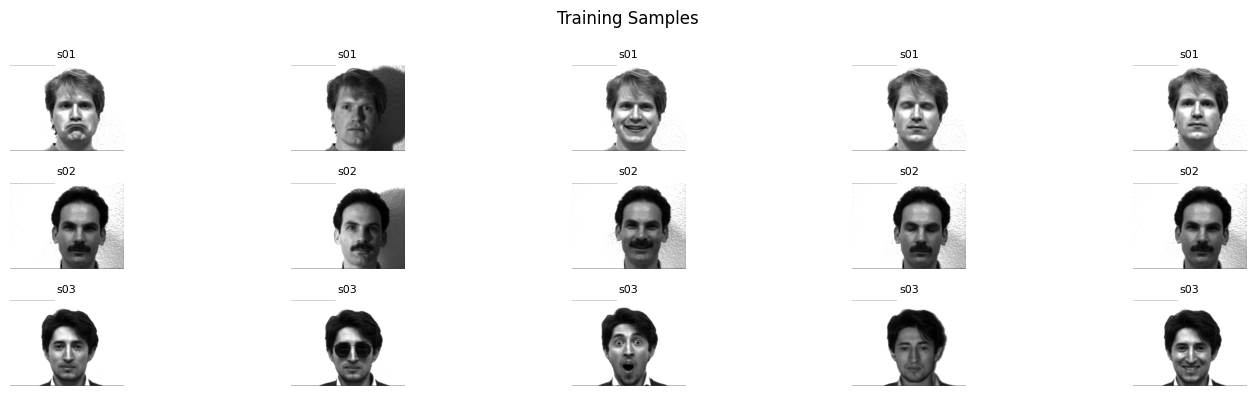

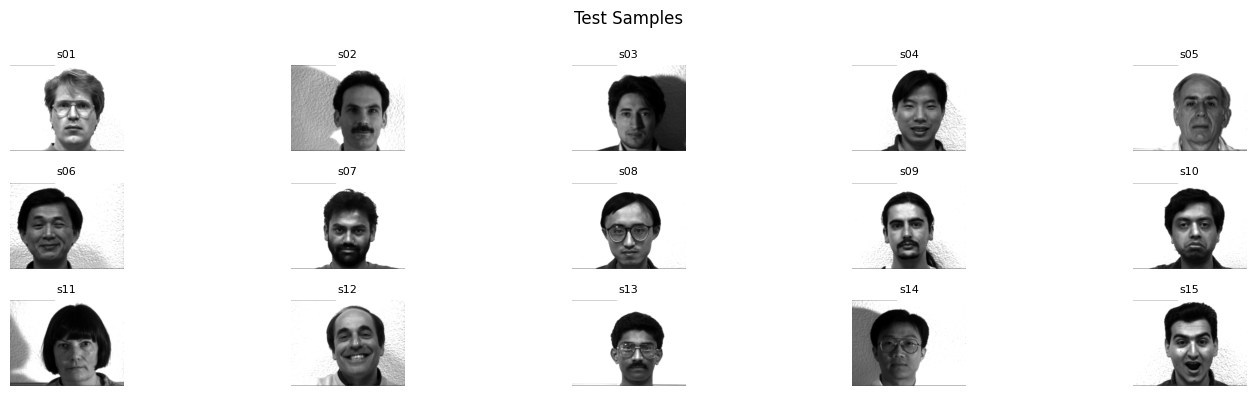

In [15]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, seed=42):
    """
    Split data: randomly select n_train images for training per person,
    then randomly select 1 image from the remaining as test.
    """
    random.seed(seed)
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        if len(imgs) <= n_train:
            raise ValueError(
                f"Person '{label}' has only {len(imgs)} images, "
                f"need at least {n_train + 1} (n_train={n_train} + 1 for test)."
            )
        indices = list(range(len(imgs)))
        random.shuffle(indices)

        # First n_train shuffled indices -> training
        train_indices = indices[:n_train]
        # From remaining, randomly pick 1 -> test
        remaining = indices[n_train:]
        test_index = random.choice(remaining)

        for i in train_indices:
            train_imgs.append(imgs[i])
            train_labels.append(label)

        test_imgs.append(imgs[test_index])
        test_labels.append(label)

    return train_imgs, train_labels, test_imgs, test_labels

# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")

n_train = 5  # The number of training images per person

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

n_imgs_per_person = len(next(iter(persons.values())))
print(f"\nn_train = {n_train}, n_test = 1")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

### Training Kernel Matrix 

In [16]:
# sigma = 5 * mean(d_NN), where d_NN_i is the nearest-neighbor distance for each training point.

sigma = auto_select_sigma(X_train, multiplier=5)
print(f"Auto-selected \u03c3 = {sigma:.2f}")
print(f"  (equivalent gamma = {1/(2*sigma**2):.2e})")

K_train = gaussian_kernel(X_train, X_train, sigma)
print(f"\nTraining kernel matrix shape: {K_train.shape}")

Auto-selected σ = 46325.54
  (equivalent gamma = 2.33e-10)

Training kernel matrix shape: (75, 75)


###  Center the Kernel Matrix

Centered kernel matrix shape: (75, 75)
Row mean (should ≈ 0): 4.74e-16


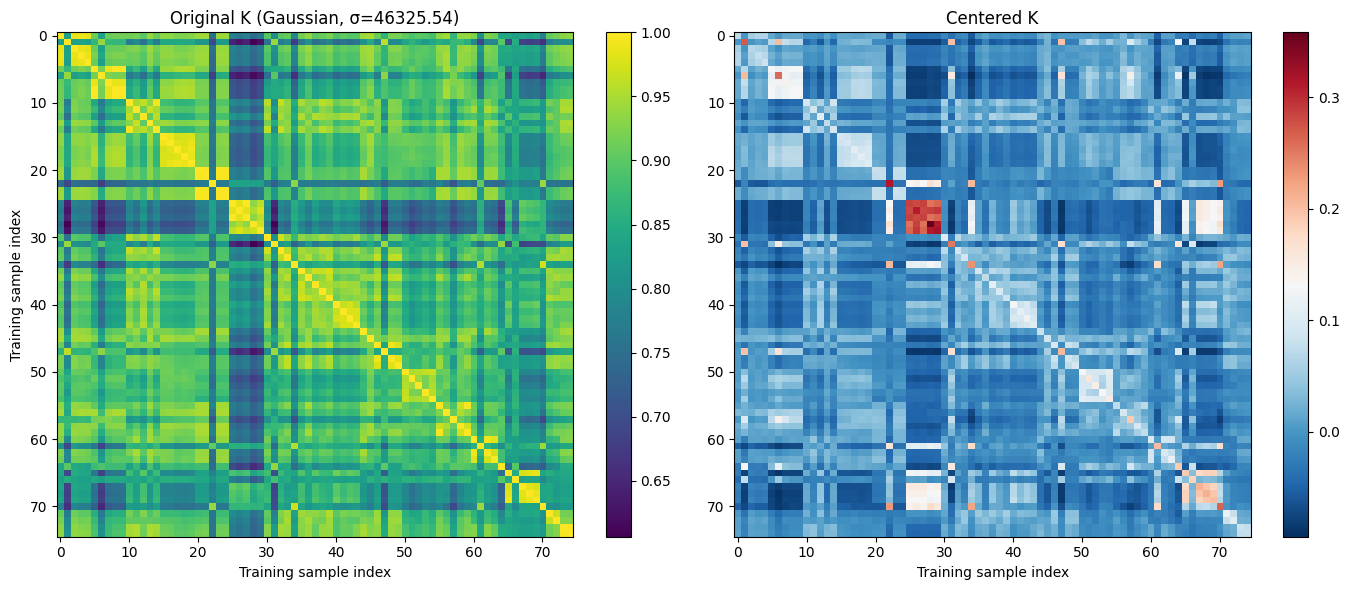

In [17]:
# K_c = K - 1_N K - K 1_N + 1_N K 1_N
N = K_train.shape[0]
one_N = np.ones((N, N)) / N

K_centered = K_train - one_N @ K_train - K_train @ one_N + one_N @ K_train @ one_N

print(f"Centered kernel matrix shape: {K_centered.shape}")
print(f"Row mean (should \u2248 0): {np.abs(K_centered.mean(axis=1)).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(K_train, cmap='viridis', aspect='auto')
axes[0].set_title(f"Original K (Gaussian, \u03c3={sigma:.2f})")
axes[0].set_xlabel("Training sample index")
axes[0].set_ylabel("Training sample index")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(K_centered, cmap='RdBu_r', aspect='auto')
axes[1].set_title("Centered K")
axes[1].set_xlabel("Training sample index")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

### Eigendecomposition and Normalization

Number of positive eigenvalues: 72 / 75
Top 10 eigenvalues: [3.07691402 1.43483395 0.84047335 0.65674291 0.53305599 0.46513515
 0.35498055 0.29209112 0.28125204 0.23297537]
alphas shape: (75, 72)


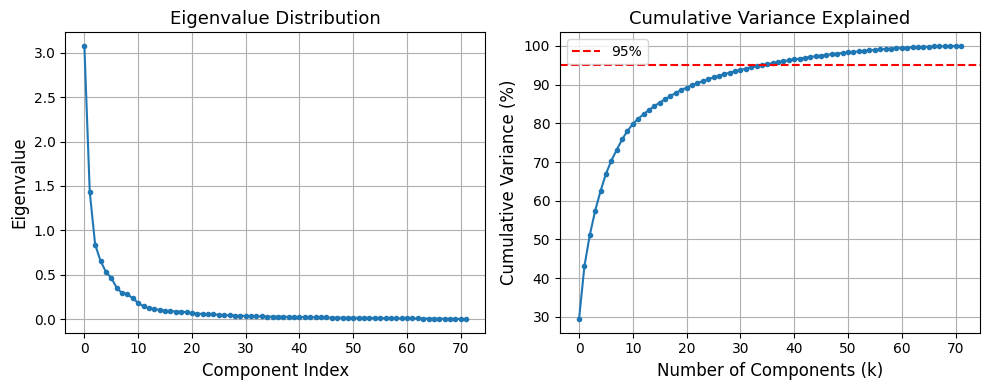


Components needed to reach 95% cumulative variance: 35


In [18]:
eigenvalues, eigenvectors = np.linalg.eigh(K_centered)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


# Keep only positive eigenvalues (discard numerical noise)
pos_mask = eigenvalues > 1e-10
eigenvalues = eigenvalues[pos_mask]
eigenvectors = eigenvectors[:, pos_mask]

print(f"Number of positive eigenvalues: {len(eigenvalues)} / {K_centered.shape[0]}")
print(f"Top 10 eigenvalues: {eigenvalues[:10]}")

# Normalize: alpha^(m) = eigenvector^(m) / sqrt(lambda_m)
alphas = eigenvectors / np.sqrt(eigenvalues)

print(f"alphas shape: {alphas.shape}")


# Visualize Eigenvalue Distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(eigenvalues, marker='o', markersize=3)
plt.xlabel("Component Index", fontsize=12)
plt.ylabel("Eigenvalue", fontsize=12)
plt.title("Eigenvalue Distribution", fontsize=13)
plt.grid(True)

cumulative_ratio = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
plt.subplot(1, 2, 2)
plt.plot(cumulative_ratio, marker='o', markersize=3)
plt.xlabel("Number of Components (k)", fontsize=12)
plt.ylabel("Cumulative Variance (%)", fontsize=12)
plt.title("Cumulative Variance Explained", fontsize=13)
plt.axhline(y=95, color='r', linestyle='--', label='95%')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

k_95 = np.argmax(cumulative_ratio >= 95) + 1
print(f"\nComponents needed to reach 95% cumulative variance: {k_95}")

### KPCA Projection Visualization


Projected training data: (75, 72)
Projected test data: (15, 72)


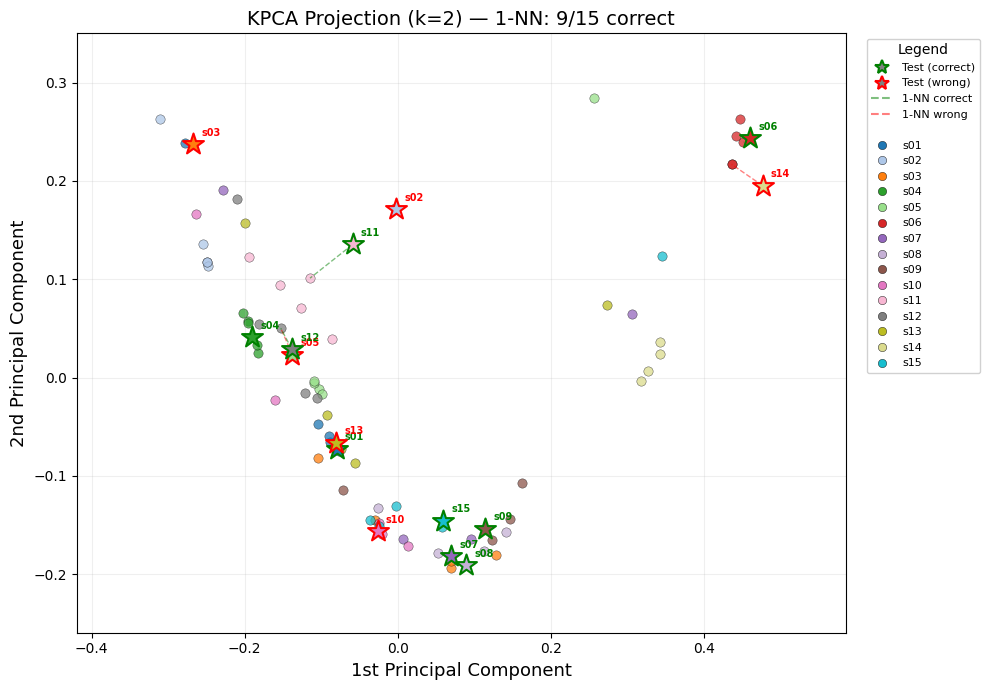

In [19]:
# Full projection onto all components
X_train_proj = K_centered @ alphas
K_test = gaussian_kernel(X_test, X_train, sigma=sigma)
N_train = X_train.shape[0]
N_test = X_test.shape[0]
one_N_test = np.ones((N_test, N_train)) / N_train
K_test_centered = K_test - one_N_test @ K_train - K_test @ one_N + one_N_test @ K_train @ one_N
X_test_proj = K_test_centered @ alphas

print(f"Projected training data: {X_train_proj.shape}")
print(f"Projected test data: {X_test_proj.shape}")


# 2D Visualization
from scipy.spatial.distance import cdist
from matplotlib.lines import Line2D

k = 2
X_train_2d = X_train_proj[:, :k]
X_test_2d = X_test_proj[:, :k]

# 1-NN using first 2 components
dists_k = cdist(X_test_2d, X_train_2d, metric="euclidean")
nn_indices = np.argmin(dists_k, axis=1)
nn_preds = y_train[nn_indices]
correct = nn_preds == y_test
n_correct = np.sum(correct)

# Distinct color per person
unique_labels = sorted(set(y_train))
n_labels = len(unique_labels)
cmap = plt.cm.tab20 if n_labels <= 20 else plt.cm.gist_ncar
person_colors = {label: cmap(i / n_labels) for i, label in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(10, 7))

# Training points — colored by person, with black edge for visibility
for label in unique_labels:
    mask = y_train == label
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               color=person_colors[label],
               marker="o", s=45, alpha=0.75, edgecolors="black", linewidths=0.3)

# Lines: test -> nearest train
for i in range(len(y_test)):
    nn_idx = nn_indices[i]
    line_color = "green" if correct[i] else "red"
    ax.plot([X_test_2d[i, 0], X_train_2d[nn_idx, 0]],
            [X_test_2d[i, 1], X_train_2d[nn_idx, 1]],
            color=line_color, linewidth=1, alpha=0.5, linestyle="--")

# Test points — star colored by person, edge green/red for correct/wrong
for i in range(len(y_test)):
    edge_c = "green" if correct[i] else "red"
    ax.scatter(X_test_2d[i, 0], X_test_2d[i, 1],
               marker="*", s=250, c=[person_colors[y_test[i]]],
               edgecolors=edge_c, linewidths=1.5, zorder=5)
    ax.annotate(y_test[i], (X_test_2d[i, 0], X_test_2d[i, 1]),
                textcoords="offset points", xytext=(6, 6),
                fontsize=7, fontweight="bold", color=edge_c)

# Expand axis limits to avoid clipping
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
x_margin = (xmax - xmin) * 0.08
y_margin = (ymax - ymin) * 0.08
ax.set_xlim(xmin - x_margin, xmax + x_margin)
ax.set_ylim(ymin - y_margin, ymax + y_margin)

# Single combined legend outside the plot
result_handles = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gray", markersize=10,
           markeredgecolor="green", markeredgewidth=1.5, label="Test (correct)"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gray", markersize=10,
           markeredgecolor="red", markeredgewidth=1.5, label="Test (wrong)"),
    Line2D([0],[0], color="green", linestyle="--", alpha=0.5, label="1-NN correct"),
    Line2D([0],[0], color="red", linestyle="--", alpha=0.5, label="1-NN wrong"),
]
person_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=person_colors[l],
           markeredgecolor="black", markeredgewidth=0.3, markersize=6, label=l)
    for l in unique_labels
]
all_handles = result_handles + [Line2D([0],[0], color="w", label="")] + person_handles
ax.legend(handles=all_handles, bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8, framealpha=0.9, title="Legend")

ax.set_xlabel("1st Principal Component", fontsize=13)
ax.set_ylabel("2nd Principal Component", fontsize=13)
ax.set_title(f"KPCA Projection (k={k}) — 1-NN: {n_correct}/{len(y_test)} correct", fontsize=14)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Using top 30 components
Accuracy: 86.67%  (13 / 15 correct)

Sample   True         Predicted    OK
----------------------------------------
0        s01          s01          ✓
1        s02          s02          ✓
2        s03          s07          ✗
3        s04          s04          ✓
4        s05          s05          ✓
5        s06          s06          ✓
6        s07          s07          ✓
7        s08          s08          ✓
8        s09          s09          ✓
9        s10          s10          ✓
10       s11          s11          ✓
11       s12          s12          ✓
12       s13          s13          ✓
13       s14          s15          ✗
14       s15          s15          ✓

Best k = 11, accuracy = 86.67%


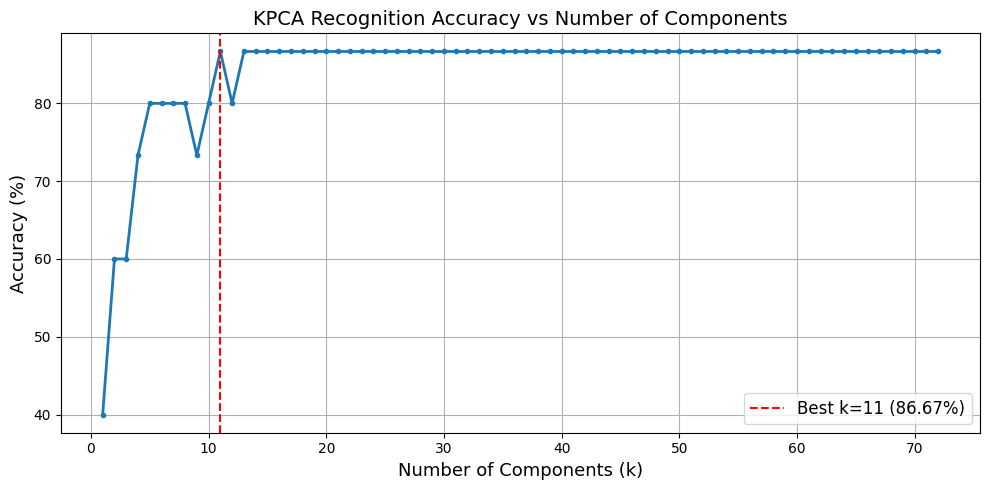

In [20]:
def nearest_neighbor_classify(X_train_proj, y_train, X_test_proj):
    """1-nearest-neighbour classifier using Euclidean distance (vectorized)."""
    # (n_test, n_train) distance matrix in one shot
    dists = np.linalg.norm(
        X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :], axis=2
    )
    return y_train[np.argmin(dists, axis=1)]



k = 30
predictions = nearest_neighbor_classify(X_train_proj[:, :k], y_train, X_test_proj[:, :k])

accuracy = np.mean(predictions == y_test) * 100
print(f"Using top {k} components")
print(f"Accuracy: {accuracy:.2f}%  ({np.sum(predictions == y_test)} / {len(y_test)} correct)")


print(f"\n{'Sample':<8} {'True':<12} {'Predicted':<12} {'OK'}")
print("-" * 40)
for i in range(len(y_test)):
    mark = "✓" if predictions[i] == y_test[i] else "✗"
    print(f"{i:<8} {y_test[i]:<12} {predictions[i]:<12} {mark}")


max_k = X_train_proj.shape[1]

# Precompute per-component squared differences: (n_test, n_train, max_k)
# Cumulative sum means cum_dist_sq[:, :, k-1] = squared distance using first k components.
diff_sq = (X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :]) ** 2
cum_dist_sq = np.cumsum(diff_sq, axis=2)

acc_list = [
    np.mean(y_train[np.argmin(cum_dist_sq[:, :, k - 1], axis=1)] == y_test) * 100
    for k in range(1, max_k + 1)
]

k_list = list(range(1, max_k + 1))
best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)
print(f"\nBest k = {best_k}, accuracy = {best_acc:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_list, acc_list, marker='o', markersize=3, linewidth=2)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k} ({best_acc:.2f}%)')
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA Recognition Accuracy vs Number of Components", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Effect of Training Size on KPCA Recognition Accuracy
Sweep n_train from 2 to 10. For each training size, use the paper's auto-sigma strategy ($\sigma = 5 \cdot \text{mean}(d^{NN})$) and evaluate KPCA accuracy across different numbers of components k.

n_train =  2 | σ =   61459.75 | max_k =  29 | best accuracy = 73.33% at k = 17
n_train =  3 | σ =   56670.09 | max_k =  44 | best accuracy = 80.00% at k = 11
n_train =  4 | σ =   51419.99 | max_k =  58 | best accuracy = 86.67% at k = 9
n_train =  5 | σ =   46325.54 | max_k =  72 | best accuracy = 86.67% at k = 11
n_train =  6 | σ =   45234.05 | max_k =  88 | best accuracy = 80.00% at k = 21
n_train =  7 | σ =   44038.21 | max_k = 101 | best accuracy = 66.67% at k = 9
n_train =  8 | σ =   41323.81 | max_k = 113 | best accuracy = 100.00% at k = 58
n_train =  9 | σ =   40913.71 | max_k = 128 | best accuracy = 93.33% at k = 18
n_train = 10 | σ =   41081.48 | max_k = 142 | best accuracy = 86.67% at k = 71


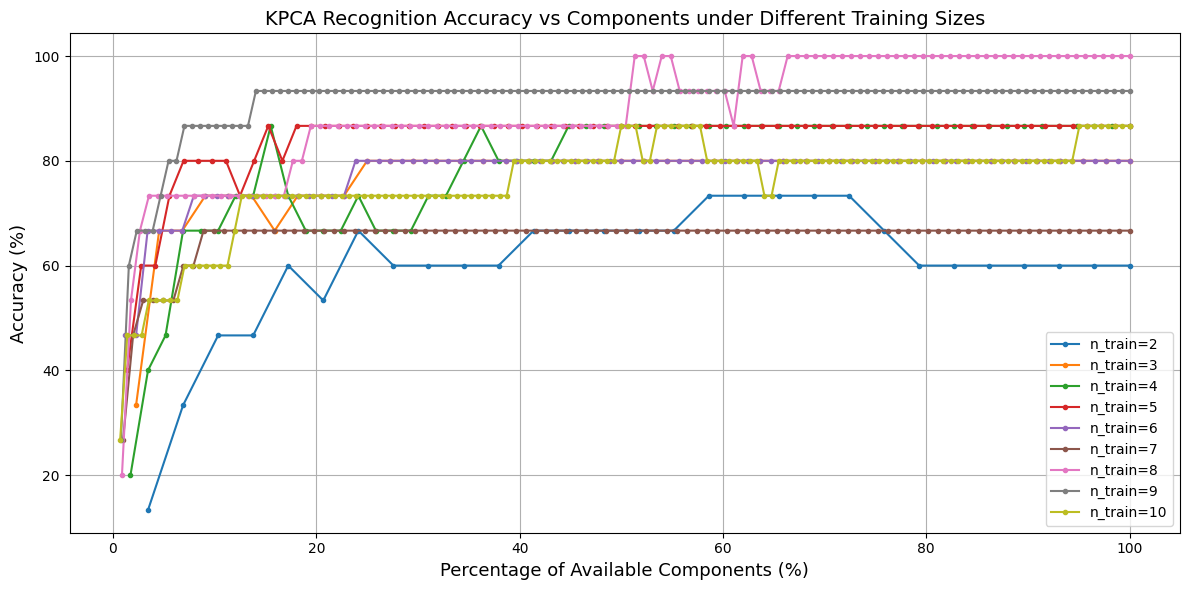

In [21]:
# ====================================================================
# KPCA Accuracy vs k under Different Training Sizes
# ====================================================================

n_train_list = list(range(2, 11))
kpca_accuracy_data = {}

for n_tr in n_train_list:
    tr_imgs, tr_labels, te_imgs, te_labels = split_data(persons, n_train=n_tr)
    X_tr = np.array([img.flatten() for img in tr_imgs])
    X_te = np.array([img.flatten() for img in te_imgs])
    y_tr = np.array(tr_labels)
    y_te = np.array(te_labels)

    N_tr = X_tr.shape[0]

    # --- Auto-select sigma for this n_train ---
    sig = auto_select_sigma(X_tr, multiplier=5)

    # --- Build KPCA projection ---
    K_tr = gaussian_kernel(X_tr, X_tr, sig)
    one_N_tr = np.ones((N_tr, N_tr)) / N_tr
    K_c = K_tr - one_N_tr @ K_tr - K_tr @ one_N_tr + one_N_tr @ K_tr @ one_N_tr

    ev, evec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]; ev = ev[idx]; evec = evec[:, idx]
    pos = ev > 1e-10; ev = ev[pos]; evec = evec[:, pos]
    al = evec / np.sqrt(ev)
    Xtr_p = K_c @ al

    K_te = gaussian_kernel(X_te, X_tr, sig)
    N_te = X_te.shape[0]
    one_te = np.ones((N_te, N_tr)) / N_tr
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N_tr + one_te @ K_tr @ one_N_tr
    Xte_p = K_te_c @ al

    max_k = Xtr_p.shape[1]
    k_list = list(range(1, max_k + 1))
    accs = []
    for k in k_list:
        dists = np.linalg.norm(Xte_p[:, np.newaxis, :k] - Xtr_p[np.newaxis, :, :k], axis=2)
        preds = y_tr[np.argmin(dists, axis=1)]
        accs.append(np.mean(preds == y_te) * 100)

    kpca_accuracy_data[n_tr] = {
        'k_list': k_list,
        'accuracy': accs,
        'sigma': sig,
        'max_k': max_k
    }
    print(f"n_train = {n_tr:>2d} | \u03c3 = {sig:>10.2f} | max_k = {max_k:>3d} "
          f"| best accuracy = {max(accs):.2f}% at k = {k_list[np.argmax(accs)]}")

# --- Plot: Accuracy vs k (percentage of available components) ---
plt.figure(figsize=(12, 6))
for n_tr in n_train_list:
    data = kpca_accuracy_data[n_tr]
    k_pct = [k / data['max_k'] * 100 for k in data['k_list']]
    plt.plot(k_pct, data['accuracy'],
             label=f"n_train={n_tr}", marker='o', markersize=3)
plt.xlabel("Percentage of Available Components (%)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA Recognition Accuracy vs Components under Different Training Sizes", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### Improvement: KPCA + LDA
Apply LDA on top of KPCA features to maximize class separability in the kernel-induced feature space.

Using auto-selected sigma = 46325.54
Reusing KPCA projections: X_train_proj (75, 72), X_test_proj (15, 72)

Best KPCA-only accuracy:  86.67%
Best KPCA+LDA accuracy:   100.00% (KPCA_k=20)
Improvement over KPCA-only: +13.33%

Sample   True         Predicted    OK
----------------------------------------
0        s01          s01          ✓
1        s02          s02          ✓
2        s03          s03          ✓
3        s04          s04          ✓
4        s05          s05          ✓
5        s06          s06          ✓
6        s07          s07          ✓
7        s08          s08          ✓
8        s09          s09          ✓
9        s10          s10          ✓
10       s11          s11          ✓
11       s12          s12          ✓
12       s13          s13          ✓
13       s14          s14          ✓
14       s15          s15          ✓


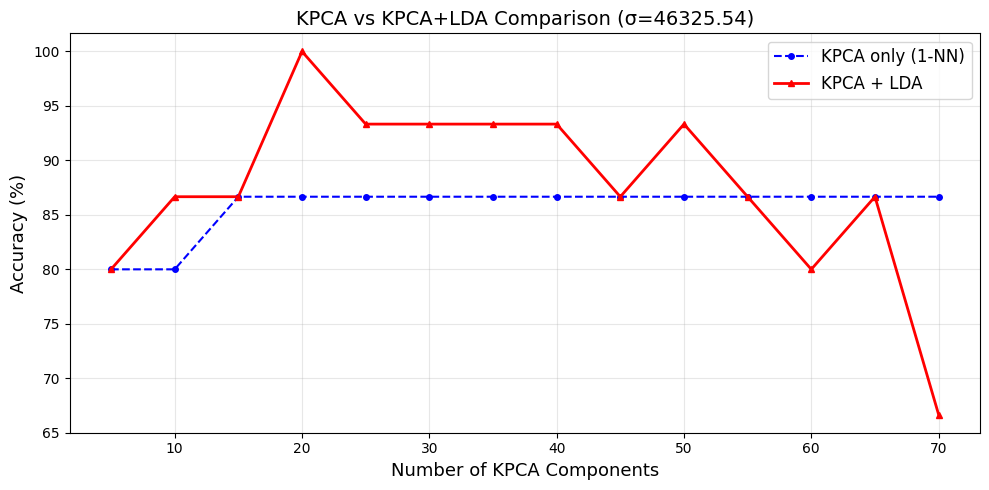

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ====================================================================
# KPCA + LDA: reuse projections from Cell 11, sweep KPCA dimensions
# ====================================================================

print(f"Using auto-selected sigma = {sigma:.2f}")
print(f"Reusing KPCA projections: X_train_proj {X_train_proj.shape}, X_test_proj {X_test_proj.shape}")

kpca_k_list = list(range(5, min(X_train_proj.shape[1], 70) + 1, 5))
kpca_lda_accs = []
kpca_only_accs = []

for kk in kpca_k_list:
    # KPCA-only accuracy (1-NN Euclidean)
    dists = np.linalg.norm(
        X_test_proj[:, np.newaxis, :kk] - X_train_proj[np.newaxis, :, :kk], axis=2
    )
    preds_kpca = y_train[np.argmin(dists, axis=1)]
    kpca_only_accs.append(np.mean(preds_kpca == y_test) * 100)

    # KPCA + LDA accuracy
    try:
        lda = LinearDiscriminantAnalysis()
        X_tr_l = lda.fit_transform(X_train_proj[:, :kk], y_train)
        X_te_l = lda.transform(X_test_proj[:, :kk])
        dists_l = np.linalg.norm(
            X_te_l[:, np.newaxis, :] - X_tr_l[np.newaxis, :, :], axis=2
        )
        preds_lda = y_train[np.argmin(dists_l, axis=1)]
        kpca_lda_accs.append(np.mean(preds_lda == y_test) * 100)
    except Exception:
        kpca_lda_accs.append(float('nan'))

best_kpca_only = max(kpca_only_accs)
best_kpca_lda = np.nanmax(kpca_lda_accs)
best_kpca_lda_k = kpca_k_list[np.nanargmax(kpca_lda_accs)]

print(f"\nBest KPCA-only accuracy:  {best_kpca_only:.2f}%")
print(f"Best KPCA+LDA accuracy:   {best_kpca_lda:.2f}% (KPCA_k={best_kpca_lda_k})")
print(f"Improvement over KPCA-only: +{best_kpca_lda - best_acc:.2f}%")

# Per-sample results for best KPCA+LDA
lda_best = LinearDiscriminantAnalysis()
X_tr_l_best = lda_best.fit_transform(X_train_proj[:, :best_kpca_lda_k], y_train)
X_te_l_best = lda_best.transform(X_test_proj[:, :best_kpca_lda_k])
dists_best = np.linalg.norm(
    X_te_l_best[:, np.newaxis, :] - X_tr_l_best[np.newaxis, :, :], axis=2
)
preds_best = y_train[np.argmin(dists_best, axis=1)]

print(f"\n{'Sample':<8} {'True':<12} {'Predicted':<12} {'OK'}")
print("-" * 40)
for i in range(len(y_test)):
    mark = "\u2713" if preds_best[i] == y_test[i] else "\u2717"
    print(f"{i:<8} {y_test[i]:<12} {preds_best[i]:<12} {mark}")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(kpca_k_list, kpca_only_accs, 'b--o', markersize=4, label='KPCA only (1-NN)')
plt.plot(kpca_k_list, kpca_lda_accs, 'r-^', markersize=5, linewidth=2, label='KPCA + LDA')
plt.xlabel("Number of KPCA Components", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title(f"KPCA vs KPCA+LDA Comparison (\u03c3={sigma:.2f})", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()